In [14]:
!python -m pip install gymnasium==0.28.1
!python -m pip install stable-baselines3[extra] gymnasium

  Using cached gymnasium-0.28.1-py3-none-any.whl.metadata (9.2 kB)
Using cached gymnasium-0.28.1-py3-none-any.whl (925 kB)
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 1.3.0
    Uninstalling gymnasium-1.3.0:
      Successfully uninstalled gymnasium-1.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
stable-baselines3 2.9.0 requires gymnasium<2.0,>=0.29.1, but you have gymnasium 0.28.1 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.28.1 which is incompatible.
  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
Using cached gymnasium-1.3.0-py3-none-any.whl (953 kB)
  Attempting uninstall: gymnasium
    Found existing installation: gymnasium 0.28.1
    Uninstalling gymnasium-0.28.1:
      Successfully uninstalled gymnasium-0.28.1


In [15]:
import gymnasium as gym
import stable_baselines3 as sb3
import matplotlib.pyplot as plt
import cv2

print(gym.__version__)
print(sb3.__version__)

1.3.0
2.9.0


In [16]:
env=gym.make("CartPole-v1",render_mode="rgb_array")

In [17]:
obs,info =env.reset()
print(obs)
print(info)

[ 0.02975042  0.04588225 -0.02420717 -0.00599495]
{}


(400, 600, 3)


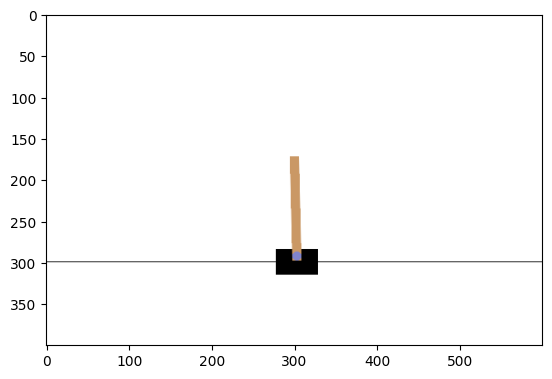

In [18]:
frame=env.render()
print(frame.shape)
plt.imshow(frame)

In [19]:
print(f"the observation space : {env.observation_space}")
print(f"the action space : {env.action_space}")
print(f"random obsrvation : {env.observation_space.sample()}")
print(f"random action : {env.action_space.sample()}")

the observation space : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
the action space : Discrete(2)
random obsrvation : [-3.270222   -0.3018932  -0.14463241 -0.38030583]
random action : 1


[ 0.03066806 -0.14888433 -0.02432707  0.2789531 ]
1.0
False


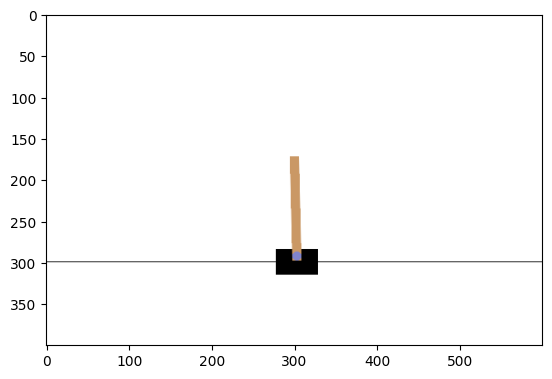

In [20]:
obs,reward,terminated,truncated,info=env.step(0)
print(obs)
print(reward)
print(terminated)
frame=env.render()
plt.imshow(frame)

In [21]:
def test_model(env,model,video=None,msg=None):
  obs,info=env.reset()
  frame=env.render()
  ep_len=0
  ep_rew=0
  while True:
    action,_=model.predict(obs)
    obs,reward,terminated,truncated,info=env.step(action)
    ep_rew +=reward
    if video:
      frame=env.render()
      frame= cv2.cvtColor(frame,cv2.COLOR_RGB2BGR)
      frame= cv2.putText(frame,msg,(10,25),cv2.FONT_HERSHEY_SIMPLEX,1,(0,0,0),2,cv2.LINE_AA)
      video.write(frame)
    ep_len+=1
    if terminated or truncated:
      return ep_len,ep_rew


In [22]:
class DummyModel():
  def __init__(self,env):
    self.env=env
  def predict(self,obs):
    action= self.env.action_space.sample()
    return action,None

In [30]:
FPS=30
FOURCC = cv2.VideoWriter.fourcc('m','p','4','v')
VIDEO_FILENAME="1-random.mp4"
width=frame.shape[1]
height=frame.shape[0]
video=cv2.VideoWriter(VIDEO_FILENAME,FOURCC,FPS,(width,height))
video=cv2.VideoWriter(VIDEO_FILENAME,FOURCC,FPS,(width,height))
dummy_model=DummyModel(env)
for ep in range(5):
  ep_len,ep_rew=test_model(env,dummy_model,video,f"Random, episode {ep}")
  print(f"Episode {ep} | length {ep_len} | reward {ep_rew}")
video.release()

Episode 0 | length 17 | reward 17.0
Episode 1 | length 34 | reward 34.0
Episode 2 | length 10 | reward 10.0
Episode 3 | length 16 | reward 16.0
Episode 4 | length 23 | reward 23.0


In [31]:
model=sb3.DQN('MlpPolicy',env,learning_rate=0.0001,learning_starts=1000,batch_size=32,gamma=0.99,train_freq=256,gradient_steps=128,target_update_interval=10,policy_kwargs={'net_arch' :[256,256]},verbose=0)

In [32]:
NUM_ROUNDS= 20
NUM_TRAINING_STEPS_PER_ROUND = 5000
NUM_TESTS_PER_ROUND = 100
MODEL_FILENAME_BASE="cartpole.dqn"
VIDEO_FILENAME="2-training.mp4"
video=cv2.VideoWriter(VIDEO_FILENAME,FOURCC,FPS,(width,height))
avg_ep_lens= []
avg_ep_rews= []
for rnd in range(NUM_ROUNDS):
  model.learn(total_timesteps=NUM_TRAINING_STEPS_PER_ROUND)
  model.save(f"{MODEL_FILENAME_BASE}_{rnd}")
  avg_ep_len=0
  avg_ep_rew=0
  for ep in range(NUM_TESTS_PER_ROUND):
    if ep==0:
      ep_len,ep_rew=test_model(env,model,video,f"Round {rnd}")
    else:
      ep_len,ep_rew=test_model(env,model)
    avg_ep_len+=ep_len
    avg_ep_rew+=ep_rew
  avg_ep_len/=NUM_TESTS_PER_ROUND
  avg_ep_lens.append(avg_ep_len)
  avg_ep_rew /=NUM_TESTS_PER_ROUND
  avg_ep_rews.append(avg_ep_rew)
  print(f"Round {rnd} | length {avg_ep_len} | reward {avg_ep_rew}")
video.release()





Round 0 | length 76.33 | reward 76.33
Round 1 | length 158.06 | reward 158.06
Round 2 | length 236.13 | reward 236.13
Round 3 | length 227.28 | reward 227.28
Round 4 | length 217.4 | reward 217.4
Round 5 | length 186.13 | reward 186.13
Round 6 | length 191.35 | reward 191.35
Round 7 | length 152.89 | reward 152.89
Round 8 | length 148.19 | reward 148.19
Round 9 | length 161.53 | reward 161.53
Round 10 | length 190.76 | reward 190.76
Round 11 | length 219.96 | reward 219.96
Round 12 | length 244.31 | reward 244.31
Round 13 | length 196.95 | reward 196.95
Round 14 | length 195.11 | reward 195.11
Round 15 | length 272.35 | reward 272.35
Round 16 | length 282.32 | reward 282.32
Round 17 | length 253.95 | reward 253.95
Round 18 | length 370.95 | reward 370.95
Round 19 | length 469.73 | reward 469.73


In [35]:
MODEL_FILENAME = "cartpole.dqn_19"
VIDEO_FILENAME = "3-testing.mp4"
model=sb3.DQN.load(MODEL_FILENAME)
video=cv2.VideoWriter(VIDEO_FILENAME,FOURCC,FPS,(width,height))
ep_len,ep_rew=test_model(env,model,video,MODEL_FILENAME)
print(f"Episode length: {ep_len}, reward: {ep_rew}")
video.release()


Episode length: 500, reward: 500.0
